In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
os.chdir(os.path.dirname(os.path.abspath("__file__")))

In [3]:
# ============
# Load Classes
# ============

classes = [
    "camel",
    "crocodile",
    "dragon",
    "elephant",
    "lion",
    "panda",
    "rhinoceros",
    "squirrel",
    "tiger",
    "zebra",
]

X_list, y_list = [], []

for i, cls in enumerate(classes):
    data = np.load(f"data/full_numpy_bitmap_{cls}.npy")[:80000]
    labels = np.full(len(data), i)
    X_list.append(data)
    y_list.append(labels)

In [4]:
# ===================
# Create full arrays
# ===================

X = np.concatenate(
    X_list,
    axis=0,
).reshape(-1, 1, 28, 28)
y = np.concatenate(y_list, axis=0,)

In [5]:
# ===================
# Create DataLoaders
# ===================

X = X / 255.0 # normalize

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

X_train, X_test, y_train, y_val = train_test_split(X_t, y_t, train_size=0.8, random_state=42)


train_dl = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_dl = DataLoader(TensorDataset(X_test, y_val), batch_size=32, shuffle=True)

In [6]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        logits = self.sequential(x)
        return logits

In [7]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
model = ConvolutionalNetwork().to(device)

learning_rate = 1e-3
batch_size = 32
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [8]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    total_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        if batch % 1000 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss {loss:>7f}\t[{current:>5d}/{size:>5d}]")

    return total_loss / num_batches


def evaluate(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct_top1, correct_top3 = 0, 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)
            test_loss += loss_fn(outputs, y).item()

            correct_top1 += (outputs.argmax(1) == y).type(torch.float).sum().item()


            _, top3_preds = outputs.topk(3, dim=1, largest=True, sorted=True)
            correct_top3 += (top3_preds == y.unsqueeze(1)).any(dim=1).sum().item()
            
    test_loss /= num_batches
    top1 = correct_top1 / size * 100
    top3 = correct_top3 / size * 100
    print(f"Test Error:\n  Top-1 Accuracy: {top1:>0.1f}%  |  Top-3 Accuracy: {top3:>0.1f}%  |  Avg Loss: {test_loss:>8f}\n")
    return test_loss, top1

In [9]:
epochs = 5
train_loss = []
val_loss = []
val_accuracy = []
for t in range(epochs):
    print(f"epoch {t + 1}\n-------------------------------------")
    train_loss.append(train(train_dl, model, loss_fn, optimizer))
    loss, accuracy = evaluate(val_dl, model, loss_fn)
    val_loss.append(loss)
    val_accuracy.append(accuracy)
print("Done!")

epoch 1
-------------------------------------
loss 2.315821	[   32/640000]
loss 0.673872	[32032/640000]
loss 0.658306	[64032/640000]
loss 0.992086	[96032/640000]
loss 0.451196	[128032/640000]
loss 0.795265	[160032/640000]
loss 0.623620	[192032/640000]
loss 0.390629	[224032/640000]
loss 0.476717	[256032/640000]
loss 0.724795	[288032/640000]
loss 0.469152	[320032/640000]
loss 0.765807	[352032/640000]
loss 0.799121	[384032/640000]
loss 0.837144	[416032/640000]
loss 0.565286	[448032/640000]
loss 0.531748	[480032/640000]
loss 0.547028	[512032/640000]
loss 0.518598	[544032/640000]
loss 0.693836	[576032/640000]
loss 0.530476	[608032/640000]
Test Error:
  Top-1 Accuracy: 83.7%  |  Top-3 Accuracy: 95.5%  |  Avg Loss: 0.499890

epoch 2
-------------------------------------
loss 0.627349	[   32/640000]
loss 0.294686	[32032/640000]
loss 0.296540	[64032/640000]
loss 0.508757	[96032/640000]
loss 0.331896	[128032/640000]
loss 0.628885	[160032/640000]
loss 0.444377	[192032/640000]
loss 0.437691	[22403

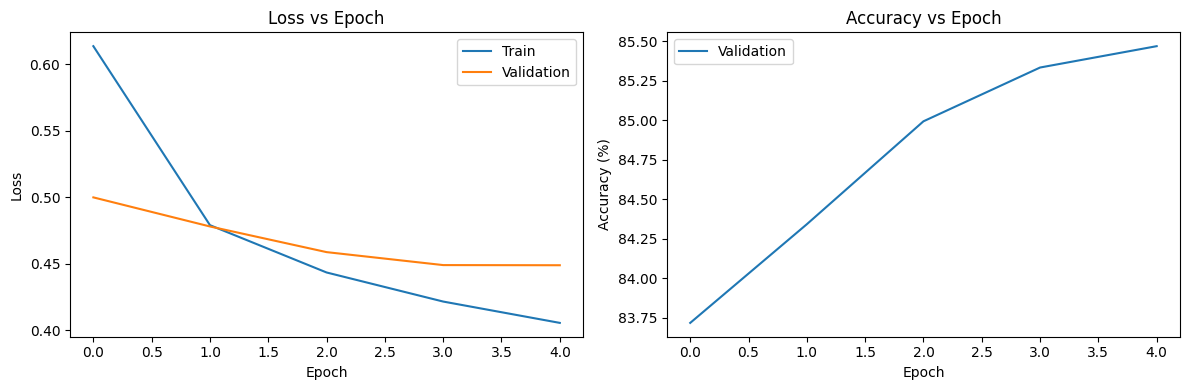

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_loss, label="Train")
ax1.plot(val_loss, label="Validation")
ax1.set_title("Loss vs Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(val_accuracy, label="Validation")
ax2.set_title("Accuracy vs Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()

plt.tight_layout()
plt.show()

In [12]:
# ==========
# Test Set
# ==========

classes = [
    "camel",
    "crocodile",
    "dragon",
    "elephant",
    "lion",
    "panda",
    "rhinoceros",
    "squirrel",
    "tiger",
    "zebra",
]

X_list, y_list = [], []

for i, cls in enumerate(classes):
    data = np.load(f"data/full_numpy_bitmap_{cls}.npy")[80000:]
    labels = np.full(len(data), i)
    X_list.append(data)
    y_list.append(labels)

X = np.concatenate(X_list, axis=0).reshape(-1, 1, 28, 28)
y = np.concatenate(y_list, axis=0)

X = X / 255.0

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

test_dl = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=True)

In [13]:
evaluate(test_dl, model, loss_fn)

Test Error:
  Top-1 Accuracy: 85.5%  |  Top-3 Accuracy: 95.8%  |  Avg Loss: 0.448447



(0.44844677144235245, 85.51877656672757)